In [7]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [2]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
INTERIMDIR = CONFIGS['filepaths']['interim']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'

MODELS = {}
for name,rc in CONFIGS['experiments']['pod']['runs'].items():
    MODELS[name] = rc['description']
for name,rc in CONFIGS['experiments']['nn']['runs'].items():
    MODELS[name] = rc['description']
for name,rc in CONFIGS['experiments']['sr']['optimizedeqs'].items():
    MODELS[name] = rc['description']

In [3]:
def spatial_r2(ytrue,ypred):
    ssres = ((ytrue-ypred)**2).sum('time',skipna=True)
    sstot = ((ytrue-ytrue.mean('time',skipna=True))**2).sum('time',skipna=True)
    return (1-ssres/sstot).squeeze()

def scalar_r2(ytrue,ypred,landmask):
    ssres = ((ytrue-ypred)**2).sum('time',skipna=True).values.ravel()
    sstot = ((ytrue-ytrue.mean('time',skipna=True))**2).sum('time',skipna=True).values.ravel()
    finite = np.isfinite(ssres)&np.isfinite(sstot)
    land   = landmask.ravel()
    r2land   = float(1-ssres[land&finite].sum()/sstot[land&finite].sum())
    r2ocean  = float(1-ssres[~land&finite].sum()/sstot[~land&finite].sum())
    return r2land,r2ocean

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELS:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:
        predtp = predtp.mean('seed')
    if 'complexity' in predtp.dims:
        predtp = predtp.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,predtp,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELS)} models!')

Loaded 9/9 models!


In [5]:
with xr.open_dataset(os.path.join(INTERIMDIR,'lf.nc')) as ds:
    lf = ds[list(ds.data_vars)[0]].squeeze().load()
ref  = next(iter(results.values()))[0].isel(time=0)
lf   = lf.interp(lat=ref.lat,lon=ref.lon,method='nearest')
land = (lf.values>=0.5)

names = sorted([n for n in MODELS if n in results],key=lambda n:float(spatial_r2(*results[n]).mean()))
if 'pod_bl' in names and 'sr_full' in names:
    ipod,isr = names.index('pod_bl'),names.index('sr_full')
    if isr<ipod:
        names.remove('sr_full')
        names.insert(names.index('pod_bl')+1,'sr_full')

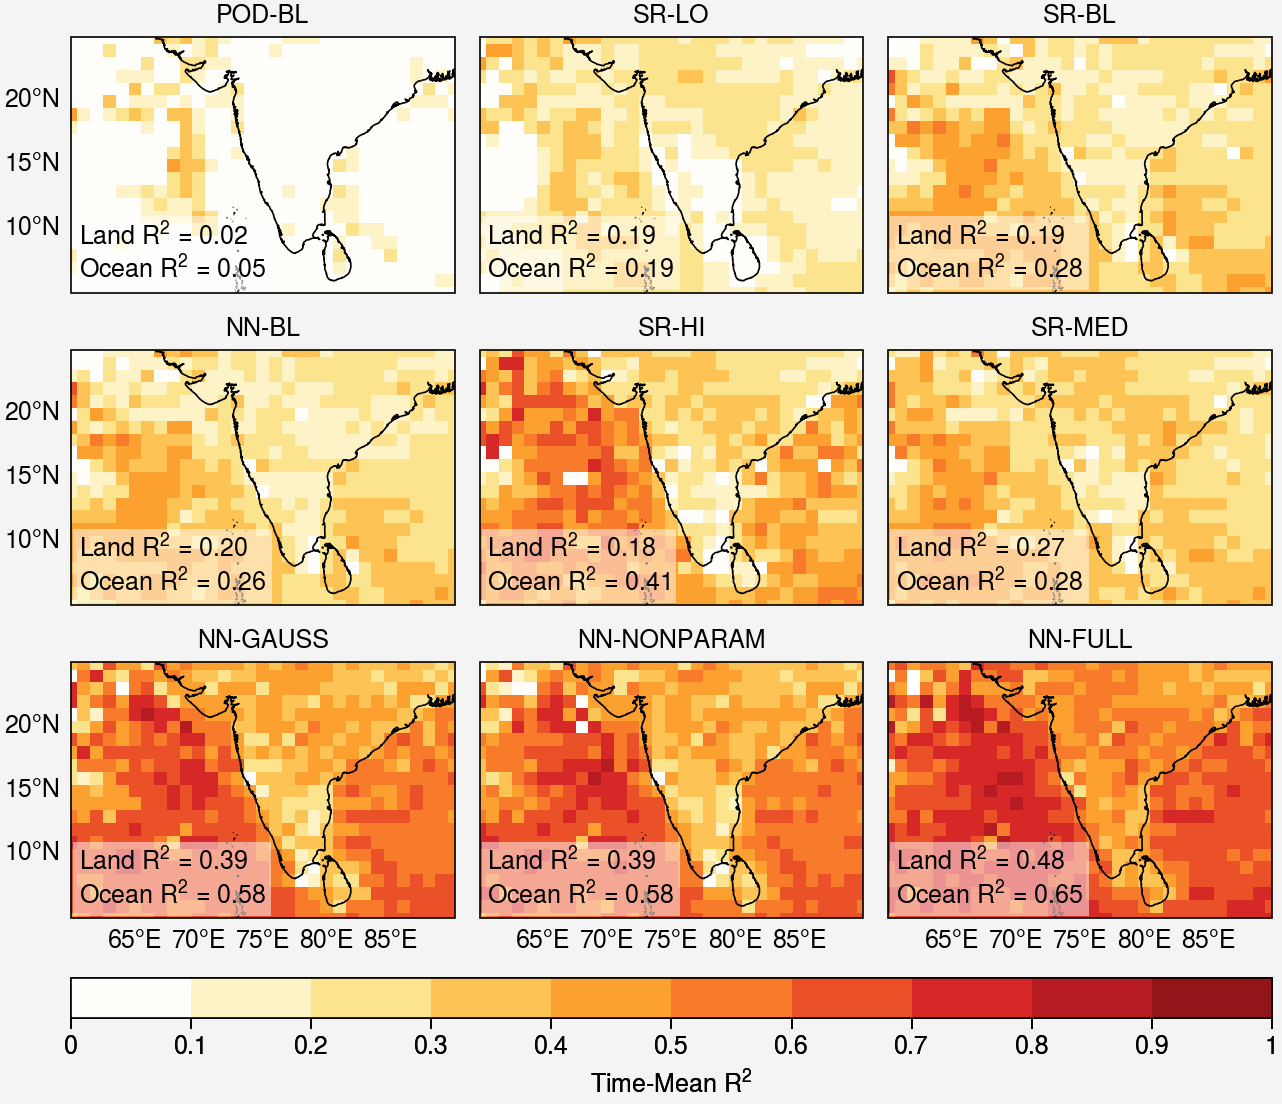

In [6]:
fig,axs = pplt.subplots(nrows=3,ncols=3,proj='cyl',figwidth=6.5,share=True)
axs.format(grid=False,coast=True,latlim=LATRANGE,lonlim=LONRANGE,latlines=[10,15,20],lonlines=5)
axs[-1,:].format(lonlabels='b')
axs[:,0].format(latlabels='l')
m = None
for ax,name in zip(axs,names):
    ytrue,ypred = results[name]
    r2 = spatial_r2(ytrue,ypred)
    r2land,r2ocean = scalar_r2(ytrue,ypred,land)
    m = ax.pcolormesh(r2.lon,r2.lat,r2,cmap='ColdHot',cmap_kw={'left':0.5},vmin=0,vmax=1,levels=11)
    ax.format(title=MODELS.get(name,name))
    ax.text(0.02,0.03,f'Land R$^2$ = {r2land:.2f} \nOcean R$^2$ = {r2ocean:.2f}',transform=ax.transAxes,ha='left',va='bottom',
            bbox=dict(facecolor='white',alpha=0.5,edgecolor='none',pad=2))
fig.colorbar(m,loc='b',label='Time-Mean R$^2$',ticks=0.1)
pplt.show()
fig.save('../figs/fig_3.jpg')